In [4]:
#TASK 1:Load & Understand Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv(r"C:\Users\NANDINI\Downloads\winequality (1).csv")
df.head()
df.tail()
df.sample(5)
#Data Type:Numerical tabular data
#Each row:one wine sample
#Each column:chemical property
#Target column:quality

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1304,7.6,0.790,0.21,2.3,0.087,21.0,68.0,0.99550,3.12,0.44,9.2,5
216,8.7,0.625,0.16,2.0,0.101,13.0,49.0,0.99620,3.14,0.57,11.0,5
660,7.2,0.520,0.07,1.4,0.074,5.0,20.0,0.99730,3.32,0.81,9.6,6
463,8.1,0.660,0.70,2.2,0.098,25.0,129.0,0.99720,3.08,0.53,9.0,5
1329,7.4,0.600,0.26,2.1,0.083,17.0,91.0,0.99616,3.29,0.56,9.8,6


In [6]:
#TASK 2: Basic Data Inspection
df.columns
df.shape
df.dtypes
df.describe()
# Data inspection helps understand structure, scale, and issues before training models.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
#TASK 3: Missing Values Analysis
df.isnull()
df.isnull().sum()
#No missing values present
#If present: fill using mean/median or remove rows

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

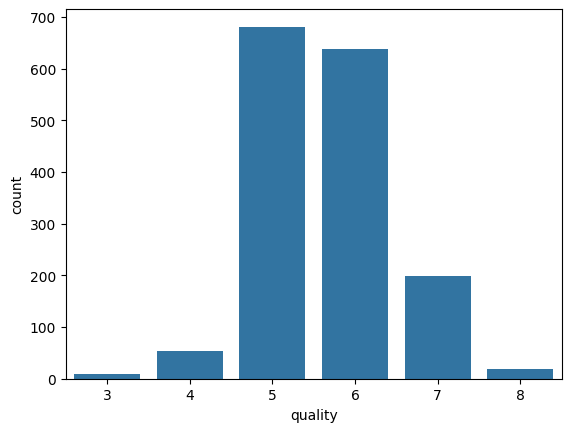

In [9]:
#TASK 4: Exploratory Data Analysis (EDA)
df['quality'].value_counts()
sns.countplot(x='quality', data=df)
plt.show()
#Observations:
#Most wines have quality between 5–6
#Very few high-quality wines
#Dataset is slightly imbalanced
#EDA->Understand distribution,Detect imbalance,Helps model selection 

In [15]:
#TASK 5:Convert the Problem into a Classification Task
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
df[['quality', 'quality_label']].head()
#Binary classification is simpler and more useful in real systems

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [17]:
#TASK 6: Feature and Target Separation
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']
print("Features (X) – first 5 rows:")
display(X.head())
print("Target (y) – first 5 values:")
display(y.head())
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
#Using quality as input causes data leakage

Features (X) – first 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


Target (y) – first 5 values:


0    0
1    0
2    0
3    0
4    0
Name: quality_label, dtype: int64

Shape of X: (1599, 11)
Shape of y: (1599,)


In [20]:
#TASK 7: Train–Test Split
from sklearn.model_selection import train_test_split
# Train–Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display outputs
print("Training Features shape (X_train):", X_train.shape)
print("Testing Features shape (X_test):", X_test.shape)
print("Training Target shape (y_train):", y_train.shape)
print("Testing Target shape (y_test):", y_test.shape)
print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 values of y_train:")
display(y_train.head())
# We split data to train the model on one part and evaluate its performance on unseen data. This helps measure real-world performance.
# The model may memorize the data instead of learning patterns, causing overfitting and poor performance on new data.

Training Features shape (X_train): (1279, 11)
Testing Features shape (X_test): (320, 11)
Training Target shape (y_train): (1279,)
Testing Target shape (y_test): (320,)

First 5 rows of X_train:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9



First 5 values of y_train:


493    0
354    0
342    0
834    0
705    0
Name: quality_label, dtype: int64

In [21]:
#TASK 8: Feature Scaling
from sklearn.preprocessing import StandardScaler
# Initialize scaler
scaler = StandardScaler()
# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data
X_test_scaled = scaler.transform(X_test)
# Convert scaled arrays back to DataFrame for better display
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
# Display outputs
print("First 5 rows of scaled training data:")
display(X_train_scaled_df.head())
print("\nMean of scaled training data (approx 0):")
display(X_train_scaled_df.mean())
print("\nStandard deviation of scaled training data (approx 1):")
display(X_train_scaled_df.std())
# Feature scaling ensures all features are on the same scale so that no feature dominates the model due to larger values.
# Distance-based models like KNN and SVM and gradient-based models like Logistic Regression require scaling because they rely on distance calculations and gradient descent.

First 5 rows of scaled training data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.218332,0.889712,0.192092,0.309726,-0.049642,0.691007,1.042934,1.846696,1.093500,0.458223,1.123177
1,-1.290166,-1.788783,0.652753,-0.805080,-0.455214,2.388473,3.593870,-3.004491,-0.400439,-0.401197,1.408272
2,1.494753,-0.784347,1.011045,-0.526378,0.599272,-0.957960,-0.991742,0.768655,-0.075669,0.515517,-0.587390
3,0.276351,0.861811,-0.063831,-0.665729,-0.009085,0.012020,-0.718427,0.089488,0.054238,-1.088733,-0.967516
4,0.044274,2.814880,-0.626861,2.399985,-0.313264,-0.472970,0.222990,1.199871,0.379008,-0.974144,-0.492358



Mean of scaled training data (approx 0):


fixed acidity          -1.111091e-16
volatile acidity        4.117981e-16
citric acid             1.263866e-16
residual sugar          1.527750e-17
chlorides               3.749932e-17
free sulfur dioxide    -7.638751e-17
total sulfur dioxide   -7.569308e-17
density                 2.559398e-14
pH                     -1.358309e-15
sulphates               4.152703e-16
alcohol                 4.722137e-16
dtype: float64


Standard deviation of scaled training data (approx 1):


fixed acidity           1.000391
volatile acidity        1.000391
citric acid             1.000391
residual sugar          1.000391
chlorides               1.000391
free sulfur dioxide     1.000391
total sulfur dioxide    1.000391
density                 1.000391
pH                      1.000391
sulphates               1.000391
alcohol                 1.000391
dtype: float64

In [22]:
#TASK 9: Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# Initialize models
log_reg = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
svm = SVC()
# Train models
log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("All models trained successfully!")
#Logistic Regression->Logistic Regression predicts probability using a linear equation and classifies data using a threshold.
#K-Nearest Neighbors (KNN)->KNN classifies a data point based on the majority class of its nearest neighbors.
#Decision Tree Classifier->Decision Tree splits data into branches based on feature conditions to make predictions.
#Random Forest Classifier->Random Forest combines multiple decision trees and uses majority voting to improve accuracy.
#Support Vector Machine (SVM)->SVM finds the optimal boundary that best separates classes in high-dimensional space.

All models trained successfully!


In [23]:
#TASK 10: Model Evaluation and Comparison
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm)
}
accuracy_df = pd.DataFrame(accuracy_results.items(),columns=["Model", "Accuracy"])
accuracy_df
#Accuracy is the ratio of correctly predicted samples to total samples.
#Different algorithms learn data differently. Comparing models helps select the most accurate and reliable one.
#Random Forest performed best because it combines multiple decision trees and reduces overfitting.
#A single model may be biased or underfit. Comparing models improves confidence in results.

,Model,Accuracy
0,Logistic Regression,0.865625
1,KNN,0.881250
2,Decision Tree,0.871875
3,Random Forest,0.900000
4,SVM,0.875000


In [24]:
#TASK 11: Pipeline and Hyperparameter Tuning
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)
#A pipeline combines multiple steps like scaling and model training into a single workflow to avoid errors and data leakage.
#GridSearchCV automatically tests different parameter combinations and selects the best one using cross-validation.
#Cross-validation evaluates the model on multiple data splits, giving a more reliable performance estimate.
#It is systematic, unbiased, and finds optimal parameters efficiently.


Best Parameters:
{'svc__C': 10, 'svc__kernel': 'rbf'}

Best Cross-Validation Accuracy:
0.8944424019607844


In [25]:
#TASK 12: Final Conclusion
#In this project, the Wine Quality dataset was studied and understood using its chemical properties.
#Exploratory Data Analysis showed that most wines have quality scores between 5 and 6, with fewer high-quality wines.
#Several machine learning models were trained and evaluated for performance.
#Random Forest and Support Vector Machine performed the best based on accuracy.
#This project helped in understanding data preprocessing, feature scaling, model training, and evaluation.
#The overall workflow followed in this project is similar to real-world machine learning applications used for quality prediction and decision-making.